# M9.1A — Frozen Fourier fusion (packing + Stage-B LR)

Plan: [`plans/milestone_09/09_camera_view_fusion_plan.md`](../../plans/milestone_09/09_camera_view_fusion_plan.md).  
**Canonical RMSE / Fourier-vs-GAP story:** Final Report **M9 Step 1**. This notebook keeps the **Fourier packing ladder** and Stage-B LR curves.

**Conclusion:** With a frozen WIN 3J Fourier trunk, DeepSets ≳ mean-pool ≳ ordered concat; xyz-mean remains a strong control.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


ROOT=.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from tomography_ml_validation.milestone_09 import describe_paths, m9_corpus_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
READ_CHECKPOINTS = True
cfg_paths = m9_corpus_paths(ROOT, data_mode=DATA_MODE, read_checkpoints=READ_CHECKPOINTS)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(cfg_paths))
print(f"results_dir={display_path(cfg_paths['results_dir'])}")
print(
    f"epochs={cfg_paths['num_epochs']}  stride={cfg_paths['angle_stride_deg']}  "
    f"load_existing={cfg_paths['load_existing']}"
)


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache
results_dir=checkpoints/m9
epochs=200  stride=60.0  load_existing=True


In [3]:
from IPython.display import display

from tomography_ml import get_device
from tomography_ml.studies import DEFAULT_LR_STAGE_B, DEFAULT_LR_STAGE_B_GRID
from tomography_ml_validation.milestone_09 import M9FusionConfig, run_m9_frozen_fusion_family
from tomography_ml_validation.plotting import plot_m9_lr_study, plot_m9_rmse_ladder
import tomography_ml_validation.milestone_09.validation as m9_validation
from gummybear_validation.notebook_tools import run_installed_pytest_test

device = get_device()
print(f"device={device}")
run_installed_pytest_test(m9_validation, "test_m9_1_frozen_fusion_pattern_ids")


device=mps
M9.1
Test executed: test_m9_1_frozen_fusion_pattern_ids()

pytest:
../../venv/lib/python3.12/site-packages/tomography_ml_validation/milestone_09/validation.py . [100%]
============================== 1 passed in 2.27s ===============================

Test proves: 09_1 frozen fusion keeps distinct Fourier vs GAP pattern IDs.


## Run or load Fourier family (pooled overlay is in `09_1B`)


M9 fourier: views=(0.0, 60.0, 120.0, 180.0, 240.0, 300.0)  epochs=200  patience=40  batch=16  lr_stage_a=0.03  RUN_LR_STUDY=True  SKIP_TRAIN=True
Loaded Stage A from checkpoints/m9/m09_frozen_fourier_fusion.pt
SKIP_TRAIN: loaded checkpoints/m9/m09_frozen_fourier_fusion.pt (10 comparison rows)


,variant_id,display_label,fusion_pattern,packing,backbone_kind,n_views,split,encoder_frozen,lr_stage_b,lr_selection,RMSE_total,RMSE_X,RMSE_Y,RMSE_Z,learned_parameter_count
0,f1_single_view_reference,SV ref,single_view_fourier_reference,NaN,fourier,1,test,False,NaN,NaN,1.073708,1.293249,1.116672,0.734232,40323
1,f1_shared_xyz_mean_control,xyz mean,shared_xyz_mean,xyz_mean,fourier,6,test,True,NaN,NaN,0.935772,1.133843,0.858460,0.777465,40323
2,m09_1_compact_fusion_mlp_mean_pool_frozen_fourier,mean-pool MLP,compact_fusion_mlp_mean_pool_frozen_fourier,mean_pool,fourier,6,test,True,0.003,fixed_lr,0.823857,0.979193,0.684782,0.780049,16899
3,m09_1_deepsets_fourier,DeepSets Fourier,deepsets_fourier,deepsets_fourier,fourier,6,test,True,0.003,fixed_lr,0.744225,0.870066,0.569465,0.761778,33411
4,m09_1_compact_fusion_mlp_frozen_fourier,ordered concat,compact_fusion_mlp_frozen_fourier,ordered_concat,fourier,6,test,True,0.003,fixed_lr,0.744584,0.859849,0.657960,0.700689,98819
5,f1_single_view_reference,SV ref,single_view_fourier_reference,NaN,fourier,1,validation,False,NaN,NaN,1.376299,1.943008,0.949913,1.002488,40323
6,f1_shared_xyz_mean_control,xyz mean,shared_xyz_mean,xyz_mean,fourier,6,validation,True,NaN,NaN,1.319425,1.933242,0.841124,0.881893,40323
7,m09_1_compact_fusion_mlp_mean_pool_frozen_fourier,mean-pool MLP,compact_fusion_mlp_mean_pool_frozen_fourier,mean_pool,fourier,6,validation,True,0.003,fixed_lr,1.101770,1.674228,0.518239,0.755034,16899
8,m09_1_deepsets_fourier,DeepSets Fourier,deepsets_fourier,deepsets_fourier,fourier,6,validation,True,0.003,fixed_lr,1.259773,1.869993,0.691577,0.886527,33411
9,m09_1_compact_fusion_mlp_frozen_fourier,ordered concat,compact_fusion_mlp_frozen_fourier,ordered_concat,fourier,6,validation,True,0.003,fixed_lr,1.070634,1.570778,0.553691,0.815387,98819


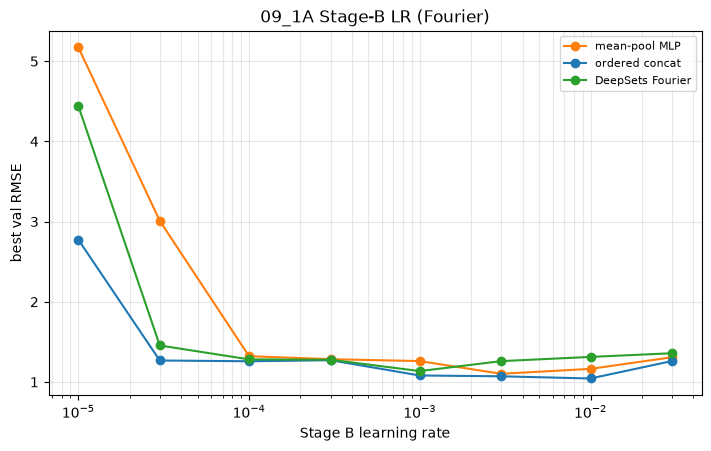

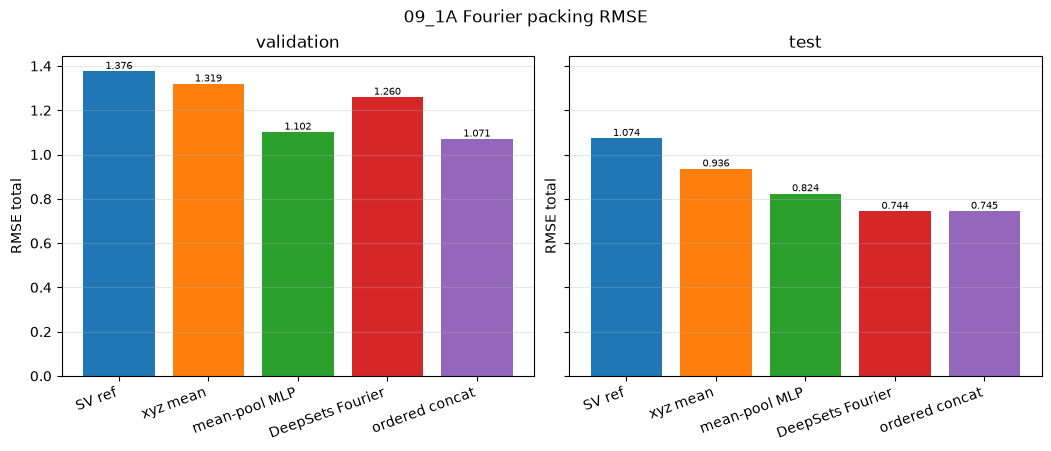

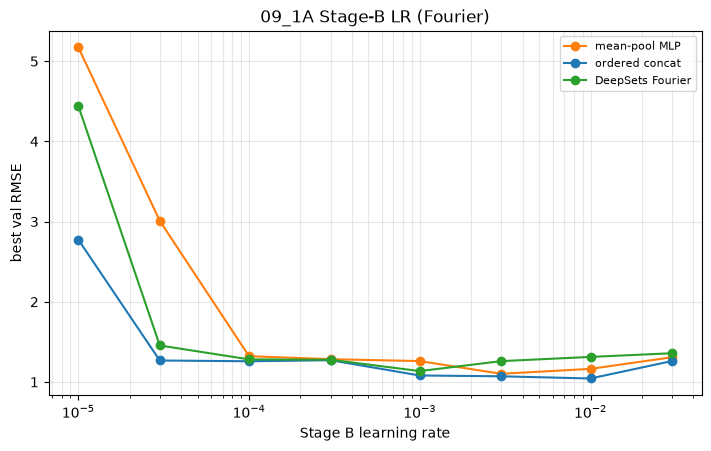

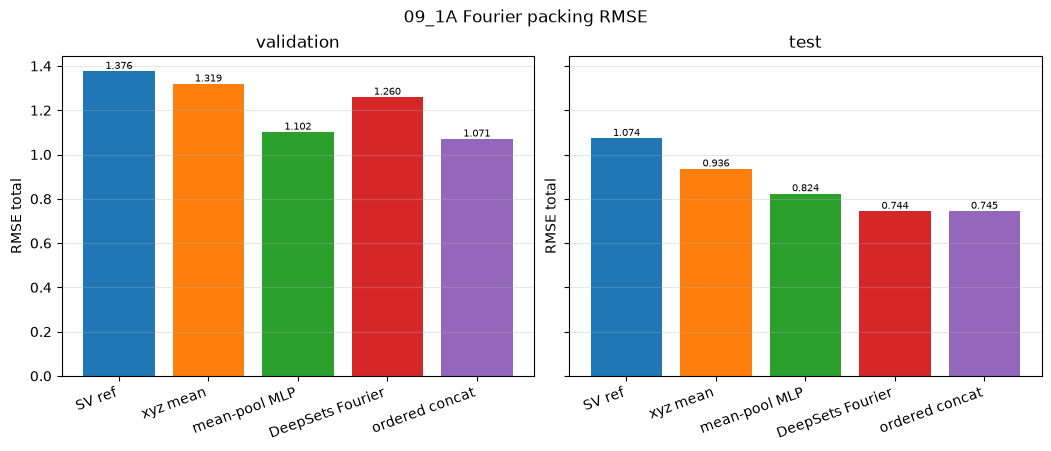

In [4]:
out = run_m9_frozen_fusion_family(
    M9FusionConfig(
        family="fourier",
        workbook_path=cfg_paths["workbook_path"],
        data_root=cfg_paths["output_root"],
        results_dir=cfg_paths["results_dir"],
        stl_root=ROOT,
        device=device,
        num_epochs=cfg_paths["num_epochs"],
        early_stop_patience=cfg_paths["early_stop_patience"],
        angle_stride_deg=cfg_paths["angle_stride_deg"],
        run_lr_study=cfg_paths["run_lr_study"],
        lr_stage_b_grid=DEFAULT_LR_STAGE_B_GRID,
        lr_stage_b_mean_pool=DEFAULT_LR_STAGE_B,
        lr_stage_b_ordered_concat=DEFAULT_LR_STAGE_B,
        lr_stage_b_deepsets=DEFAULT_LR_STAGE_B,
        load_existing=cfg_paths["load_existing"],
        retrain=cfg_paths["retrain"],
    )
)
display(out.comparison_df)
fig_lr = plot_m9_lr_study(out.lr_study_df, family="fourier", title="09_1A Stage-B LR (Fourier)")
if fig_lr is not None:
    display(fig_lr)
display(plot_m9_rmse_ladder(out.comparison_df, family="fourier", title="09_1A Fourier packing RMSE"))


See Final Report M9 Step 1 for the Fourier **vs GAP** overlay. Combined plots live in `09_1B`.
